In [1]:
import os, re, glob , pycircos, pybedtools
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.signal import savgol_filter
import statsmodels.api as sm


In [2]:
# Base directories
main_dir = Path("/Volumes/Intenso_SSD/Methylation_data")
input_dir = main_dir / "Original_data"
results_dir = main_dir / "Results"

# Sub-directories
dmr_dir = input_dir / "DMR_files"
cpg_dir = input_dir / "CpG_files"
tss_dir = input_dir / "TSS_files"
hypermethylated_output_dir = results_dir / "Upwards_methylated"
hypomethylated_output_dir = results_dir / "Downwards_methylated"
bed_output_dir = results_dir / "BED_files"
cpg_and_tss_output_dir = results_dir / "Corrected_CpGIs_"

# Columns to keep in the output DMR CSV files
columns_to_keep = ['Chromosome', 'Start', 'End', 'SiteCount', 'Length', 'Percentage', 'FoldChange']

directories_to_create = [
    results_dir,
    hypermethylated_output_dir,
    hypomethylated_output_dir,
    bed_output_dir,
    cpg_and_tss_output_dir
]

# Create the output directories if they don't exist
for directory in directories_to_create:
   directory.mkdir(parents=True, exist_ok=True)

sns.set_style('ticks')
    

In [3]:
# Define the transformation function that corrects the original DMR files if the have any format flaws
def transform_row(row):
    # Check if Length is negative
    if row['Length'] < 0:
        # Make Length positive
        row['Length'] = abs(row['Length'])
        row['End'], row['Length'] = row['Length'], row['End']
        row['Start'], row['End'] = row['End'], row['Start']
    
    return row

# Function to short chromomosomes in the format 1,2,3...X,Y
def chrom_sorter(chrom):
    chrom = chrom[3:]  # Remove 'chr' prefix
    if chrom.isdigit():  
        return int(chrom)
    elif chrom == 'X':
        return 23
    elif chrom == 'Y':
        return 24
    else:
        return 25  # Sort any non-standard chromosome identifiers at the end


In [4]:
patient_dmrs = {}

# Iterate over each DMR file in the input directory
for filename in os.listdir(dmr_dir):
    if filename.endswith('.csv'):
        # Extract patient ID from the filename using regular expression
        match = re.search(r'([NR|R]+)_(AZA|DAC)_(\d+)', filename)
        if match:
            patient_id = match.group(1)
            treatment = match.group(2)
        else:
            # Handle cases where the pattern doesn't match
            print(f"Could not extract patient ID and treatment from the filename: {filename}")
            continue
        
        # Specify input and output file paths
        input_file_path = dmr_dir / filename
        output_file_path = results_dir / filename

        hypermethylated_output_file_path = hypermethylated_output_dir / f"{Path(filename).stem}_upwards.csv"
        hypomethylated_output_file_path = hypomethylated_output_dir / f"{Path(filename).stem}_downwards.csv"

        patient_dmrs[patient_id] = (output_file_path, hypermethylated_output_file_path, hypomethylated_output_file_path)

        patient_data = pd.read_csv(input_file_path, delimiter=',', low_memory = False)
        patient_data = patient_data.apply(transform_row, axis=1)
        patient_data = patient_data[columns_to_keep].drop_duplicates()
        patient_data['Percentage'] = patient_data['Percentage'].astype(float)
        patient_data = patient_data.rename(columns={
            'Chromosome': 'chrom',
            'Start': 'chromStart',
            'End': 'chromEnd',
            'SiteCount': 'LpnPI-sites',
            'Percentage': 'methRatio',
        })

        patient_data['log10(methRatio)'] = np.log10(patient_data['methRatio'])
        patient_data['chromSort'] = patient_data['chrom'].apply(chrom_sorter)
        patient_data = patient_data.sort_values(by=['chromSort', 'chromStart']).drop('chromSort', axis=1)

        # Apply filters to keep only regions with FoldChange >=2, meaning either an increase or decrease in methylation level by at least 100%.
        # Also keep regions that have at least 20 LpnPI-sites, indicating significant methylation or demethylation.
        patient_data = patient_data[(patient_data['FoldChange'] >= 2) & (patient_data['LpnPI-sites'] >= 20)]

        # Remove chromosomes of alternative and random contig from the dataset.
        patient_data = patient_data[patient_data['chrom'].str.match(r'^chr((\d{1,2})|(X|Y))$')]
        patient_data = patient_data.drop(columns=['LpnPI-sites'])

        hypermethylated_patient_data = patient_data[patient_data['log10(methRatio)'] > 0] # hypermethylated regions
        hypomethylated_patient_data = patient_data[patient_data['log10(methRatio)'] < 0] # hypomethylated regions

        hypermethylated_patient_data.to_csv(hypermethylated_output_file_path, index=False, sep=',')
        hypomethylated_patient_data.to_csv(hypomethylated_output_file_path, index=False, sep=',')
        patient_data.to_csv(output_file_path, index=False, sep=',')
        

In [5]:
# Lists to group the CpGIs and TSS files for the 2 patients that don't have preprocessed DMR files
patient_6281 = [cpg_dir/"6281_CpG.csv", tss_dir/"6281_TSS.csv"]
patient_5889 = [cpg_dir/"5889_CpG.csv", tss_dir/"5889_TSS.csv"]

def format_file(input_file, output_directory):
    patient_file = pd.read_csv(input_file, low_memory=False)
    patient_file = patient_file.rename(columns={
        'Chromosome': 'chrom',
        'Start': 'chromStart',
        'End': 'chromEnd',
        'Percentage(Y/X)': 'methRatio',
        'log10Score': 'log10(methRatio)'
    })

    # Keep statistically significant rows (q-value < 0.05)
    patient_file['q-value'] = pd.to_numeric(patient_file['q-value'], errors='coerce')
    patient_file = patient_file[patient_file['q-value'] < 0.05]
    patient_file['methRatio'] = pd.to_numeric(patient_file['methRatio'].str.replace(',', ''), errors='coerce')
    patient_file['log10(methRatio)'] = pd.to_numeric(patient_file['log10(methRatio)'], errors='coerce')

    hypermethylated = patient_file[patient_file['methRatio'] >= 1]
    hypomethylated = patient_file[patient_file['methRatio'] < 1]

    # Drop and recalibrate columns based on conditions
    hypermethylated = hypermethylated.drop(columns=['methRatio'])
    hypomethylated = hypomethylated.drop(columns=['log10(methRatio)'])
    
    hypermethylated['methRatio'] = 10 ** hypermethylated['log10(methRatio)']
    hypomethylated['log10(methRatio)'] = np.log10(hypomethylated['methRatio'])

    final_patient_file = pd.concat([hypermethylated, hypomethylated])
    
    # Remove chromosomes not matching the specified pattern
    final_patient_file = final_patient_file[final_patient_file['chrom'].str.match(r'^chr((\d{1,2})|(X|Y))$')]
    final_patient_file = final_patient_file.drop(columns=['Type', 'EnsembleID'])
    final_patient_file = final_patient_file.dropna(subset=['methRatio'])

    final_patient_file['FoldChange'] = final_patient_file['methRatio'].apply(lambda x: x if x >= 1 else 1/x)
    final_patient_file = final_patient_file[final_patient_file['FoldChange'] >= 2]

    # ScoreX and scoreY represents LpnPI sites pre- and post-treatment respectively 
    final_patient_file = final_patient_file.loc[(final_patient_file['ScoreX'] + final_patient_file['ScoreY']) >= 20] 
    final_patient_file['chromSort'] = final_patient_file['chrom'].apply(chrom_sorter)
    final_patient_file = final_patient_file.sort_values(by=['chromSort', 'chromStart']).drop('chromSort', axis=1)

    new_column_order = ['chrom', 'chromStart', 'chromEnd', 'ScoreX', 'ScoreY', 'methRatio',
                         'FoldChange', 'log10(methRatio)', 'FDR', 'q-value']
    final_patient_file = final_patient_file[new_column_order]

    # Construct output filename and save the processed DataFrame
    base_filename = Path(input_file).name
    output_filename = f"corrected_{base_filename}"
    output_file_path = output_directory/output_filename

    final_patient_file.to_csv(output_file_path, index=False)
    final_patient_file = final_patient_file.drop(columns=['FDR','q-value'])

    return final_patient_file

df_6281_list = [format_file(file_path, cpg_and_tss_output_dir) for file_path in patient_6281]
final_df_6281 = pd.concat(df_6281_list)

df_5889_list = [format_file(file_path, cpg_and_tss_output_dir) for file_path in patient_5889]
final_df_5889 = pd.concat(df_5889_list)


In [6]:
# Define a function to detect Differentially Methylated Regions within the CpGIs and TSS sites.
def find_DMRs(patient_file, distance_threshold, methylation_threshold):
    patient_file_sorted = patient_file.sort_values(by=['chrom', 'chromStart'])
    DMRs = []  # List to store identified DMRs.

    # Group the sorted DataFrame by chromosome and iterate over each group.
    for chrom, group in patient_file_sorted.groupby('chrom'):
        # Initialize the first DMR with the first row's data
        current_DMR = {
            'chrom': chrom,
            'start': group.iloc[0]['chromStart'],
            'end': group.iloc[0]['chromEnd'],
            'total_log10MethRatio': group.iloc[0]['log10(methRatio)'],
            'total_FoldChange': group.iloc[0]['FoldChange'],
            'total_MethRatio': group.iloc[0]['methRatio'],
            'count': 1
        }

        # Iterate over each row in the group to assess and aggregate contiguous regions into DMRs.
        for _, row in group.iterrows():
            within_distance = row['chromStart'] <= current_DMR['start'] + distance_threshold
            avg_log10MethRatio = current_DMR['total_log10MethRatio'] / current_DMR['count']
            log10methRatio_diff = abs(avg_log10MethRatio - row['log10(methRatio)'])

            if within_distance and log10methRatio_diff <= methylation_threshold:
                # Aggregate the region into the current DMR if within distance and threshold.
                current_DMR['start'] = min(current_DMR['start'], row['chromStart'])
                current_DMR['end'] = max(current_DMR['end'], row['chromEnd'])
                current_DMR['total_log10MethRatio'] += row['log10(methRatio)']
                current_DMR['total_FoldChange'] += row['FoldChange']
                current_DMR['total_MethRatio'] += row['methRatio']
                current_DMR['count'] += 1
            else:
                # Finalize the current DMR and start a new one.
                DMRs.append([
                    current_DMR['chrom'], current_DMR['start'], current_DMR['end'], current_DMR['total_log10MethRatio'],
                    current_DMR['total_FoldChange'], current_DMR['total_MethRatio'], current_DMR['count']
                ])
                current_DMR = {
                    'chrom': chrom,
                    'start': row['chromStart'],
                    'end': row['chromEnd'],
                    'total_log10MethRatio': row['log10(methRatio)'],
                    'total_FoldChange': row['FoldChange'],
                    'total_MethRatio': row['methRatio'],
                    'count': 1
                }

        # Append the last DMR for the chromosome
        DMRs.append([
            current_DMR['chrom'], current_DMR['start'], current_DMR['end'], current_DMR['total_log10MethRatio'],
            current_DMR['total_FoldChange'], current_DMR['total_MethRatio'], current_DMR['count']
        ])

    # Convert the list of DMRs to a DataFrame and calculate additional metrics.
    DMR_data = pd.DataFrame(DMRs, columns=['Chrom', 'Start', 'End', 'Total_log10MethRatio', 'Total_FoldChange', 'Total_MethRatio', 'Count'])
    DMR_data['Length'] = DMR_data['End'] - DMR_data['Start']
    DMR_data['Average_MethRatio'] = DMR_data['Total_MethRatio'] / DMR_data['Count']
    DMR_data['Average_FoldChange'] = DMR_data['Total_FoldChange'] / DMR_data['Count']
    DMR_data['Average_log10MethRatio'] = DMR_data['Total_log10MethRatio'] / DMR_data['Count']

    DMR_data = DMR_data[['Chrom', 'Start', 'End', 'Length', 'Average_MethRatio', 'Average_FoldChange', 'Average_log10MethRatio']]
    DMR_data.columns = ['chrom', 'chromStart', 'chromEnd', 'Length', 'methRatio', 'FoldChange', 'log10(methRatio)']
    DMR_data = DMR_data.drop(columns=['log10(methRatio)'])
    DMR_data['log10(methRatio)'] = np.log10(DMR_data['methRatio'])
    DMR_data[['chromStart', 'chromEnd', 'Length']] = DMR_data[['chromStart', 'chromEnd', 'Length']].astype(int)

    return DMR_data

def DMR_file_creation(patient_file, hypermethylated_filename, hypomethylated_filename, final_DMR_filename):
    hypermethylated_data = patient_file[patient_file['log10(methRatio)'] >= 0]
    hypomethylated_data = patient_file[patient_file['log10(methRatio)'] < 0]

    # Apply the function for the DMR detection to all files
    hypermethylated_data = find_DMRs(hypermethylated_data, distance_threshold = 50000, methylation_threshold = 10)
    hypermethylated_data.to_csv(hypermethylated_filename, index = False)
 
    hypomethylated_data = find_DMRs(hypomethylated_data, distance_threshold = 50000, methylation_threshold = 10)
    hypomethylated_data.to_csv(hypomethylated_filename, index = False)
    
    final_DMR_file = pd.concat([hypermethylated_data, hypomethylated_data])
    final_DMR_file = final_DMR_file.sort_values(by=['chrom', 'chromStart'], ignore_index= True)
    final_DMR_file.to_csv(final_DMR_filename, index = False)

    return final_DMR_file

# Create the DMR file for both patients.
final_DMR_file_5889 = DMR_file_creation(final_df_5889, hypermethylated_output_dir/"R_AZA_5889_upwards.csv", hypomethylated_output_dir/"R_AZA_5889_downwards.csv", results_dir/"R_AZA_5889.csv")
final_DMR_file_6281 = DMR_file_creation(final_df_6281, hypermethylated_output_dir/"R_AZA_6281_upwards.csv", hypomethylated_output_dir/"R_AZA_6281_downwards.csv", results_dir/"R_AZA_6281.csv")


In [7]:
AZA_non_responders = []
AZA_responders = []
DAC_non_responders = []

for filepath in results_dir.iterdir():
    if filepath.suffix == '.csv':
        # Extract the identifier from the Path object
        identifier = filepath.stem.split('_')[-1]
        patient_file = pd.read_csv(filepath)
        
        # Determine the category of the dataset and append it to the corresponding list
        if 'NR_AZA' in filepath.name:
            AZA_non_responders.append((identifier, patient_file))
        elif 'R_AZA' in filepath.name:
            AZA_responders.append((identifier, patient_file))
        elif 'NR_DAC' in filepath.name:
            DAC_non_responders.append((identifier, patient_file))

plots_directory = results_dir / "Plots"
plots_directory.mkdir(parents=True, exist_ok=True)

def plot_combined_metrics(patient_file, category, plots_directory, identifier):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First plot - methRatio
    sns.histplot(patient_file['methRatio'], bins=100, color='skyblue', kde=True, ax=ax1)
    ax1.set_title(f'Methylation ratio (methRatio) for {category}_{identifier}')
    ax1.set_xlabel('Methylation Ratio')
    ax1.set_ylabel('Frequency')
    
    # Second plot - log10(methRatio)
    sns.histplot(patient_file['log10(methRatio)'], bins=100, color='orange', kde=True, ax=ax2)
    ax2.set_title(f'Log10(methRatio) for {category}_{identifier}')
    ax2.set_xlabel('Log10(methRatio)')
    ax2.set_ylabel('Frequency')
    
    plt.tight_layout()
    sns.despine()
    
    plot_output_path = plots_directory / f"{category}_{identifier}_combined_metrics_plot.svg"
    plt.savefig(plot_output_path)
    plt.close(fig)

response_categories = {
    'NR_AZA': AZA_non_responders,
    'R_AZA': AZA_responders,
    'NR_DAC': DAC_non_responders
}

for category, data_list in response_categories.items():
    for identifier, patient_file in data_list:
        plot_combined_metrics(patient_file, category, plots_directory, identifier)


In [8]:
def calculate_weighted_mean_methRatio(methylation_data, identifier):
    results_list = []

    for chrom in methylation_data['chrom'].unique():
        # Get data for current chromosome
        chromosomal_methylation = methylation_data[methylation_data['chrom'] == chrom]
        
        hypermethylated = chromosomal_methylation[chromosomal_methylation['log10(methRatio)'] > 0]
        hypomethylated = chromosomal_methylation[chromosomal_methylation['log10(methRatio)'] < 0]
        
        mean_hyper = hypermethylated['log10(methRatio)'].mean() if not hypermethylated.empty else 0
        mean_hypo = hypomethylated['log10(methRatio)'].mean() if not hypomethylated.empty else 0
        
        total_observations = len(chromosomal_methylation)
        weight_hyper = len(hypermethylated) / total_observations if total_observations > 0 else 0
        weight_hypo = len(hypomethylated) / total_observations if total_observations > 0 else 0
        
        # Calculate standard errors of mean calculation
        sem_hyper = (hypermethylated['log10(methRatio)'].std() / 
                    np.sqrt(len(hypermethylated))) if not hypermethylated.empty else 0
        sem_hypo = (hypomethylated['log10(methRatio)'].std() / 
                   np.sqrt(len(hypomethylated))) if not hypomethylated.empty else 0
        
        weighted_mean = (mean_hyper * weight_hyper) + (mean_hypo * weight_hypo)
        weighted_sem = np.sqrt((sem_hyper**2 * weight_hyper) + (sem_hypo**2 * weight_hypo))
        
        results_list.append({
            'chrom': chrom,
            'weighted_mean_log10_methRatio': weighted_mean,
            'weighted_sem_log10_methRatio': weighted_sem,
            'Identifier': identifier,
            'n_hypermethylated': len(hypermethylated),
            'n_hypomethylated': len(hypomethylated),
            'mean_hyper': mean_hyper,
            'mean_hypo': mean_hypo
        })

    return pd.DataFrame(results_list)

# Generate and save a bar plot visualizing mean methylation by chromosome for each patient ID within a category.
def save_patient_barplot(data, category, chrom_order, plots_directory):
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=data,
        x='chrom',
        y='weighted_mean_log10_methRatio',
        hue='Identifier',  
        errorbar='sd', 
        palette='deep',
        width=0.9, 
        edgecolor='black',  
        linewidth=0.7 
    )
        
    plt.title(f'Median methylation by Chromosome for {category}', fontsize=16)
    ax.set_xlabel('Chromosome', fontsize=14)
    ax.set_ylabel('Median methylation', fontsize=14)

    plt.xticks(rotation=35)  
    plt.grid(True, axis='y') 
    plt.legend(title='Patient ID', bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)

    sns.despine()  
    plt.tight_layout()
    
    plot_output_path = plots_directory/f"{category}_weighted_mean_chrom_barplot.png"
    plt.savefig(plot_output_path)
    plt.close()

# Prepare a list and categorical data type for chromosome ordering.
chromosomes = ['chr' + str(i) for i in range(1, 23)] + ['chrX', 'chrY']
chrom_order = pd.Categorical(chromosomes, categories=chromosomes, ordered=True)

all_data = []  

# Iterate over categories and their respective data lists to calculate mean methylation ratios.
for category, data_list in response_categories.items():
    for identifier, df in data_list:
        df_weighted_mean = calculate_weighted_mean_methRatio(df, identifier)
        df_weighted_mean['Category'] = category 
        all_data.append(df_weighted_mean)

plot_data_df = pd.concat(all_data)

# Ensure the 'chrom' column is treated as categorical with a defined order, facilitating correct plot ordering.
plot_data_df['chrom'] = plot_data_df['chrom'].astype('category')
plot_data_df['chrom'] = plot_data_df['chrom'].cat.set_categories(chromosomes, ordered=True)

# Generate and save bar plots for each category
for category in plot_data_df['Category'].unique():
    category_data = plot_data_df[plot_data_df['Category'] == category]
    save_patient_barplot(category_data, category, chromosomes, plots_directory)
    

In [9]:
def concat_dataframes_from_tuples(tuples_list, category_name):
    # Extract just the DataFrame from each tuple and add a 'category' column
    dataframes = []
    for _, df in tuples_list:
        df_copy = df.copy() # So that we don't modify the original dataframe
        df_copy['Category'] = category_name 
        dataframes.append(df_copy)
        
    return pd.concat(dataframes, ignore_index=True)

# Combine NR_AZA and NR_DAC into one list and rename categories
combined_non_responders = AZA_non_responders + DAC_non_responders

responders_df = concat_dataframes_from_tuples(AZA_responders, 'Responders')
non_responders_df = concat_dataframes_from_tuples(combined_non_responders, 'Non_Responders')

final_df = pd.concat([responders_df, non_responders_df])


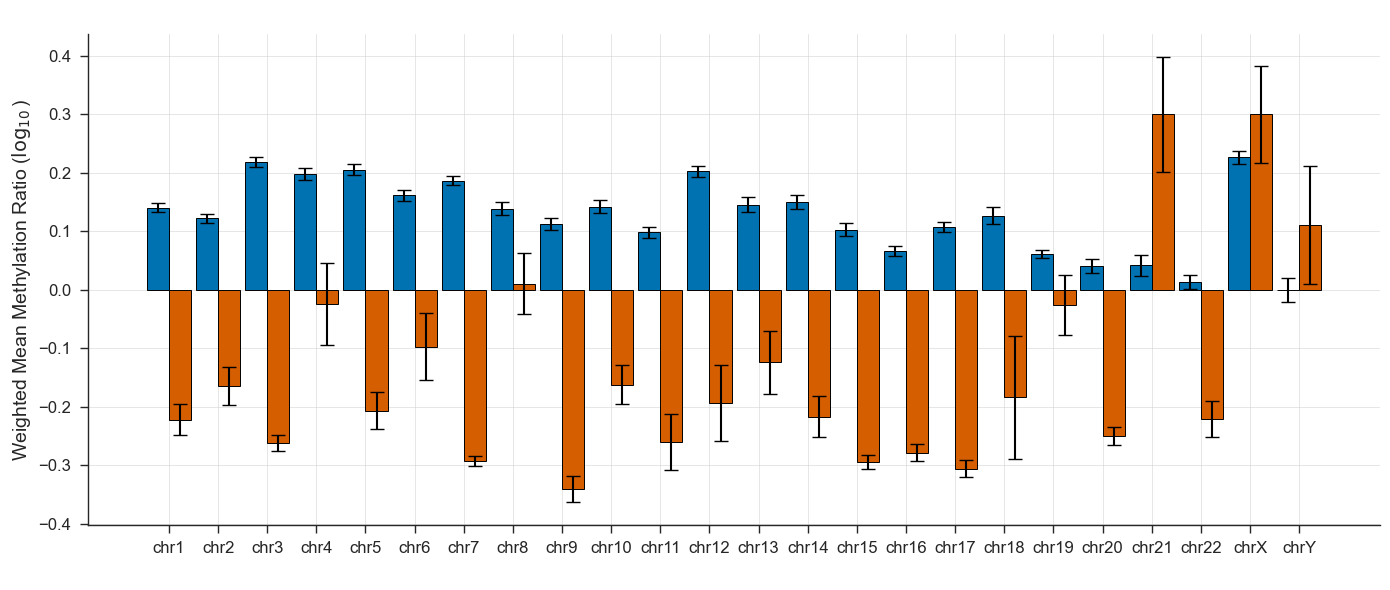

In [10]:
# Calculate the weighted means for the responders and non responders.
responder_weighted_means = calculate_weighted_mean_methRatio(responders_df, identifier="Responders")
non_responder_weighted_means = calculate_weighted_mean_methRatio(non_responders_df, identifier="Non_Responders")

combined_weighted_means = pd.concat([responder_weighted_means, non_responder_weighted_means], ignore_index=True)
combined_weighted_means['chrom'] = pd.Categorical(combined_weighted_means['chrom'], categories=chrom_order, ordered=True)

# Define bar width and positions
bar_width = 0.45
index = np.arange(len(chrom_order))

# Create a colorblind friendly colormap for Responders and Non Responders
color_map = {'Responders': '#0072b2', 'Non_Responders': '#d55e00'}

plt.figure(figsize=(14, 6))

# Define the offset from the center for each bar
# This moves the first bar to the left of the tick and the second bar to the right
offset = bar_width / 2

for i, identifier in enumerate(['Responders', 'Non_Responders']):
    group_df = combined_weighted_means[combined_weighted_means['Identifier'] == identifier]
    means = group_df.groupby('chrom', observed=True)['weighted_mean_log10_methRatio'].mean()
    sems = group_df.groupby('chrom', observed=True)['weighted_sem_log10_methRatio'].mean()

    # Adjust the position based on the identifier index (i)
    # This moves the bars so that one is on the left and one is on the right of the tick mark
    if i == 0:  # Responders
        pos = index - offset
    else:  # Non_Responders
        pos = index + offset

    plt.bar(pos, 
            means.reindex(chrom_order), 
            bar_width, 
            yerr=sems.reindex(chrom_order), 
            color=color_map[identifier], 
            label=identifier, 
            capsize=5, 
            edgecolor='black', 
            linewidth=0.7,
            zorder=2)

plt.title(' ', fontsize=16)
plt.xlabel(' ', fontsize=14)
plt.ylabel('Weighted Mean Methylation Ratio ($\log_{10}$)', fontsize=14)
plt.xticks(range(len(chrom_order)), chrom_order, fontsize=12, rotation=0)
plt.yticks(fontsize=12)
plt.grid(linestyle='-', linewidth=0.5, alpha=0.7, zorder=0)

plt.tight_layout()
sns.despine()

plt.savefig(plots_directory/"weighted_mean_chrom_barplot.svg", dpi=300)
plt.show()


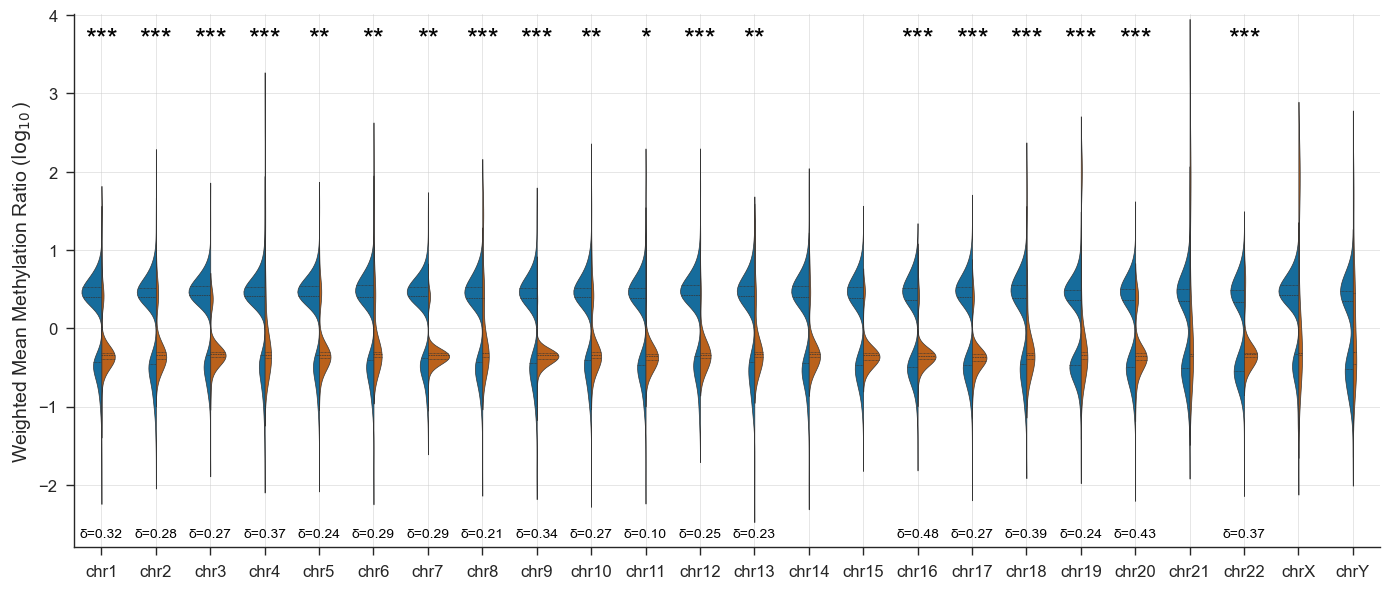

In [14]:
def cliffs_delta(x, y):
    """
    delta value between -1 and 1, where:
        - |d| < 0.147: negligible
        - 0.147 ≤ |d| < 0.33: small
        - 0.33 ≤ |d| < 0.474: medium
        - |d| ≥ 0.474: large
    """
    n1, n2 = len(x), len(y)
    dominance = 0
    
    for i in x:
        for j in y:
            if i > j:
                dominance += 1
            elif i < j:
                dominance -= 1
                
    return dominance / (n1 * n2)

def analyze_chromosome_differences(methylation_data):
    stats_results = []
    for chrom in methylation_data['chrom'].unique():
        chrom_data = methylation_data[methylation_data['chrom'] == chrom]
        
        # Split data by response category
        resp_data = chrom_data[chrom_data['Category'] == 'Responders']
        nonresp_data = chrom_data[chrom_data['Category'] == 'Non_Responders']
        
        # Calculate weighted means for both groups
        resp_weighted = calculate_weighted_mean_methRatio(resp_data, "Responders")
        nonresp_weighted = calculate_weighted_mean_methRatio(nonresp_data, "Non_Responders")
        
        # Perform Mann-Whitney U test
        statistic, pvalue = stats.mannwhitneyu(
            resp_data['log10(methRatio)'],
            nonresp_data['log10(methRatio)'],
            alternative='two-sided'
        )
        
        # Calculate Cliff's Delta
        delta = cliffs_delta(
            resp_data['log10(methRatio)'],
            nonresp_data['log10(methRatio)']
        )
        
        # Determine effect size interpretation
        if abs(delta) < 0.147:
            effect_size = 'negligible'
        elif abs(delta) < 0.33:
            effect_size = 'small'
        elif abs(delta) < 0.474:
            effect_size = 'medium'
        else:
            effect_size = 'large'
        
        stats_results.append({
            'chromosome': chrom,
            'statistic': statistic,
            'pvalue': pvalue,
            'cliffs_delta': delta,
            'effect_size': effect_size,
            'resp_weighted_mean': resp_weighted['weighted_mean_log10_methRatio'].iloc[0],
            'nonresp_weighted_mean': nonresp_weighted['weighted_mean_log10_methRatio'].iloc[0],
            'resp_weighted_sem': resp_weighted['weighted_sem_log10_methRatio'].iloc[0],
            'nonresp_weighted_sem': nonresp_weighted['weighted_sem_log10_methRatio'].iloc[0]
        })
    
    stats_df = pd.DataFrame(stats_results)
    stats_df['q_value'] = sm.stats.multipletests(stats_df['pvalue'], method='fdr_bh')[1]
    return stats_df

def create_enhanced_violin_plot(methylation_data, stats_df):
    plt.figure(figsize=(14, 6))
    sns.violinplot(x='chrom', 
                   y='log10(methRatio)', 
                   hue='Category', 
                   data=methylation_data, 
                   split=True, 
                   inner="quart",
                   palette=color_map, 
                   legend=False, 
                   order=chrom_order,
                   linewidth=0.5,
                   zorder=2)
    
    # Calculate max y value for positioning significance markers
    y_max = methylation_data['log10(methRatio)'].max() + 1
    y_min = methylation_data['log10(methRatio)'].min()
   
    # Add significance markers and delta values
    for idx, row in stats_df.iterrows():
        y_pos = y_max - 0.5
        
        # Add asterisks based on significance level
        if row['q_value'] < 0.001:
            marker = '***'
            show_delta = True
        elif row['q_value'] < 0.01:
            marker = '**'
            show_delta = True
        elif row['q_value'] < 0.05:
            marker = '*'
            show_delta = True
        else:
            marker = ''
            show_delta = False
        
        plt.text(idx, y_pos, marker, ha='center', va='bottom', 
                fontsize=20, color='black')
        
        # Add both mean difference and Cliff's Delta for significant differences
        if show_delta:
            plt.text(idx, y_min - 0.4, 
                    f'δ={row["cliffs_delta"]:.2f}', 
                    ha='center', va='top', fontsize=10, 
                    color='black', 
                    rotation=0)
            
    plt.ylim(top=y_max)
    plt.xlabel('', fontsize=14)
    plt.ylabel('Weighted Mean Methylation Ratio ($\log_{10}$)', fontsize=14)
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.grid(linestyle='-', linewidth=0.5, alpha=0.7, zorder=0)
    sns.despine()
    plt.tight_layout()
    
    plt.savefig(plots_directory/"violin_plot.svg")
    plt.show()
    
    return plt

stats_df = analyze_chromosome_differences(final_df)
violin_plot = create_enhanced_violin_plot(final_df, stats_df)


In [16]:
def process_and_split_df(methylation_data):

    methylation_data = methylation_data.drop(columns=['Length', 'methRatio', 'FoldChange'])
    
    # Split the dataframe based on the log10methratio threshold
    hypermeth = methylation_data[methylation_data['log10(methRatio)'] >= 0 ]
    hypometh = methylation_data[methylation_data['log10(methRatio)'] < 0 ]
    
    return hypermeth, hypometh

def convert_df_to_bed(methylation_data, output_file_name):
    bed = pybedtools.BedTool.from_dataframe(methylation_data)
    bed.saveas(output_file_name)

def create_BED_files(dataframe_lists, output_directory):
    for list_name, dataframes in dataframe_lists.items():
        for identifier, df in dataframes:
            upmeth_df, downmeth_df = process_and_split_df(df)
            
            upmeth_bed_file = os.path.join(output_directory, f"upwards_{list_name}_{identifier}.bed")
            convert_df_to_bed(upmeth_df, upmeth_bed_file)
            
            downmeth_bed_file = os.path.join(output_directory, f"downwards_{list_name}_{identifier}.bed")
            convert_df_to_bed(downmeth_df, downmeth_bed_file)

create_BED_files(response_categories, bed_output_dir)


In [17]:
# Split each chromosome to bins of 100kb length 
# Exact lengths for each human chromosome based on hg38.
chromosome_lengths = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
    'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
    'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
    'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
    'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
    'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
    'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415
}

bin_size = 100000  # 100kb 
bins_list = []

# Generate bins for each chromosome
for chrom, length in chromosome_lengths.items():
    num_bins = length // bin_size + (1 if length % bin_size > 0 else 0)
    for bin_num in range(num_bins):
        bin_start = bin_num * bin_size
        bin_end = min((bin_num + 1) * bin_size - 1, length)  
        bin_name = f"{chrom}_bin{bin_num + 1}"  # Assign bin names indicating the chromosome and bin number
        bins_list.append({'chrom': chrom, 'bin_start': bin_start, 'bin_end': bin_end, 'bin_name': bin_name})

bins_df = pd.DataFrame(bins_list)


In [18]:
# This dictionary comprehension creates an IntervalIndex for each chromosome found in bins_df for better efficiency
# It allows for efficient interval queries, such as finding overlaps with genomic regions.
bins_intervals = {
    chrom: pd.IntervalIndex.from_arrays(
        bins_df[bins_df['chrom'] == chrom]['bin_start'],  
        bins_df[bins_df['chrom'] == chrom]['bin_end'],
        closed='both'  # Indicates that the intervals include both start and end points
    )
    for chrom in bins_df['chrom'].unique()
}

# Precompute a mapping from (chromosome, start, end) to bin name for efficient lookup
# This dictionary maps a tuple of chromosome, start, and end positions to the corresponding bin name.
# It's useful for quickly finding the name of the bin that a genomic region belongs to.
bin_name_map = {
    (row['chrom'], row['bin_start'], row['bin_end']): row['bin_name']
    for _, row in bins_df.iterrows()
}

# Define a function to assign bins with maximum overlap to genomic regions in a dataframe
def assign_bins_with_max_overlap(methylation_data, bins_intervals, bin_name_map):

    methylation_data['bin'] = 'No match'  # Initialize a new column for the assigned bins with a default 'No match' value

    for chrom in methylation_data['chrom'].unique():
        if chrom not in bins_intervals:  # Skip chromosomes not in the bins_intervals dictionary
            continue

        chrom_df = methylation_data[methylation_data['chrom'] == chrom]
        
        # Retrieve the IntervalIndex for the current chromosome
        intervals = bins_intervals[chrom]

        for index, row in chrom_df.iterrows():
            # Create an interval for the current genomic region
            region_interval = pd.Interval(left=row['chromStart'], right=row['chromEnd'], closed='both')
            # Find bins that overlap with the region_interval
            overlapping_bins = intervals.overlaps(region_interval)

            # Skip if no bins overlap with the region
            if not any(overlapping_bins):
                continue

            # Calculate overlap lengths for each overlapping bin and select the bin with maximum overlap
            overlap_lengths = [
                (min(row['chromEnd'], bin_index.right) - max(row['chromStart'], bin_index.left), bin_index.left, bin_index.right)
                for bin_index in intervals[overlapping_bins]  # Iterate over intervals that overlap with the region
            ]
            # Select the interval with the maximum overlap
            _, max_overlap_start, max_overlap_end = max(overlap_lengths, key=lambda x: x[0])
            # Lookup the bin name using the max overlapping interval's start and end
            bin = bin_name_map.get((chrom, max_overlap_start, max_overlap_end), 'No match')
            # Update the 'bin' column in the original dataframe
            methylation_data.at[index, 'bin'] = bin

    return methylation_data 

for category, data_tuples in response_categories.items():
    processed_dataframes = []
    for identifier, df in data_tuples:
        processed_df = assign_bins_with_max_overlap(df, bins_intervals, bin_name_map)
        processed_dataframes.append((identifier, processed_df))
    response_categories[category] = processed_dataframes

methylation_df = assign_bins_with_max_overlap(final_df, bins_intervals, bin_name_map)


In [19]:
def perform_mannwhitney_u_test(bin_data):
    # Identify bins with both categories present
    bins_with_both_categories = bin_data.groupby('bin')['Category'].nunique()
    bins_with_both = bins_with_both_categories[bins_with_both_categories == 2].index.tolist()
    
    # Filter original dataset for these bins
    bin_data_filtered = bin_data[bin_data['bin'].isin(bins_with_both)]
    
    test_results = []
    
    # Perform Mann-Whitney U tests and determine significance
    for bin_name in bins_with_both:
        data_resp = bin_data_filtered[(bin_data_filtered['Category'] == 'Responders') & (bin_data_filtered['bin'] == bin_name)]['log10(methRatio)']
        data_non_resp = bin_data_filtered[(bin_data_filtered['Category'] == 'Non_Responders') & (bin_data_filtered['bin'] == bin_name)]['log10(methRatio)']
        
        # Perform Mann-Whitney U test
        stat, p_value = stats.mannwhitneyu(data_resp, data_non_resp, alternative='two-sided')
        test_results.append((bin_name, p_value))
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(test_results, columns=['Bin', 'P-Value'])
    
    return results_df

mannwhitney_results = perform_mannwhitney_u_test(final_df)


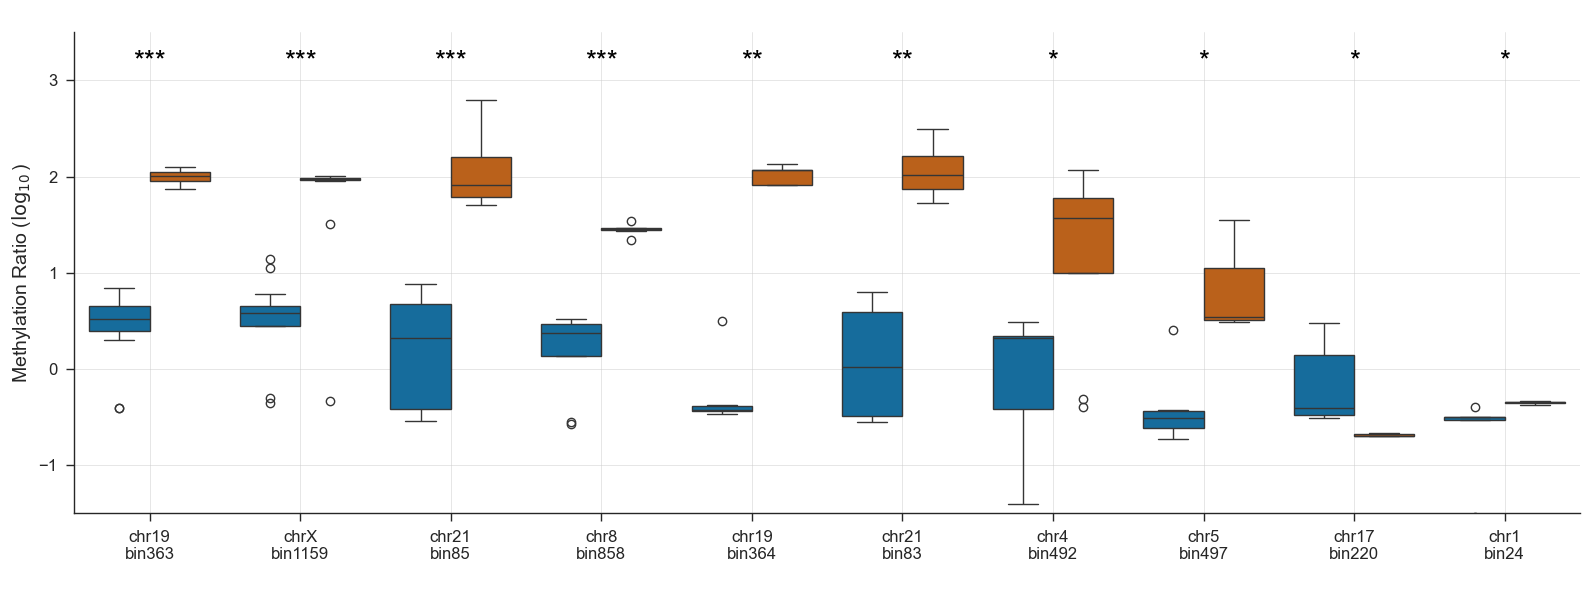

In [27]:
def plot_mannwhitney_results(patient_bin_data, mannwhitney_results_df, plot_output_path, legend_output_path, top_n_bins=10):
    significant_bins = mannwhitney_results_df[mannwhitney_results_df['P-Value'] < 0.05].sort_values(by='P-Value', ascending=True)
    significant_bins_subset = significant_bins.head(top_n_bins)
    bins_order = significant_bins_subset['Bin'].tolist()
    
    # Filter original dataset for bins of interest
    df_significant_subset = patient_bin_data[patient_bin_data['bin'].isin(bins_order)]

    plt.figure(figsize=(16, 6))

    ax = sns.boxplot(x='bin',
                     y='log10(methRatio)', 
                     hue='Category', 
                     data=df_significant_subset,
                     palette=color_map, 
                     order=bins_order, 
                     legend=False, 
                     zorder=2)
    
    
    plt.ylim(-1.5, 3.5)
    
    # Format x-tick labels by replacing underscores with newlines
    tick_positions = range(len(bins_order))
    x_tick_labels = [bin_name.replace('_', '\n') for bin_name in bins_order]
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(x_tick_labels, fontsize=12, rotation=0)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel(' ')
    ax.set_ylabel('Methylation Ratio ($\log_{10}$)', fontsize=14)
    
    plt.title(' ', fontsize=14)
    
    y_max = max(df_significant_subset['log10(methRatio)'])
    for idx, bin in enumerate(bins_order):
        row = mannwhitney_results_df[mannwhitney_results_df['Bin'] == bin].iloc[0]
        y_pos = y_max + 0.25
        
        # Add asterisks based on significance level
        if row['P-Value'] < 0.001:
            marker = '***'
        elif row['P-Value'] < 0.01:
            marker = '**'
        elif row['P-Value'] < 0.05:
            marker = '*'
        else:
            marker = ''
    
        ax.text(idx, y_pos, marker, ha='center', va='bottom', 
            fontsize=20, color='black')
    
    plt.grid(linestyle='-', linewidth=0.5, alpha=0.7, zorder=0)

    plt.tight_layout()
    sns.despine()
    plt.savefig(plot_output_path, dpi=300)
    plt.show()

    # plt.figure(figsize=(3, 2))
    # # Create dummy plot to generate legend handles
    # handles = [plt.Rectangle((0,0),1,1, fc=color) for color in color_map.values()]
    # labels = list(color_map.keys())
    
    # # Create legend
    # plt.legend(handles, labels, loc='center', frameon=False)
    # plt.axis('off')
    
    # # Save legend
    # plt.savefig(legend_output_path, dpi=300, bbox_inches='tight')
    # plt.close()
    
significant_bins = plot_mannwhitney_results(final_df, 
                                            mannwhitney_results, 
                                            plots_directory / "significant_bins_boxplot.svg", 
                                            plots_directory / "significant_bins_boxplot.svg")


In [21]:
def get_genomic_location(bin_name):
    for (chrom, start, end), bin_id in bin_name_map.items():
        if bin_id == bin_name:
            return f"{chrom}:{start}-{end}"
    return "Location not found"

def extract_bin_name(full_bin):
    return full_bin[full_bin.index('chr'):]

# Create a copy of the significant results
significant_results = mannwhitney_results[mannwhitney_results['P-Value'] < 0.05].copy()

significant_results.loc[:, 'Bin_Name'] = significant_results['Bin'].apply(extract_bin_name)
significant_results.loc[:, 'Genomic_Location'] = significant_results['Bin_Name'].apply(get_genomic_location)

significant_results = significant_results[['Bin', 'Bin_Name', 'Genomic_Location', 'P-Value']]


In [22]:
# Function to extract chromosome, start, and end from Genomic_Location
def parse_genomic_location(location):
    match = re.match(r'(chr\w+):(\d+)-(\d+)', location)
    if match:
        return match.groups()
    return None, None, None

# Apply the parsing function and create new columns
significant_results[['Chromosome', 'Start', 'End']] = significant_results['Genomic_Location'].apply(parse_genomic_location).apply(pd.Series)

# Create BED file content
bed_content = significant_results[['Chromosome', 'Start', 'End', 'Bin_Name', 'P-Value']]

# Save to BED file
bed_content.to_csv(bed_output_dir/'top_bins.bed', sep='\t', index=False, header=False)


In [23]:
# Detect the genomic ranges of the top 10 significant bins and store the results in a pandas dataframe.
if mannwhitney_results is not None:
    mannwhitney_results.sort_values(by='P-Value', ascending=True, inplace=True)
    top_10_significant_bins = mannwhitney_results.head(10)
    top_10_significant_bins = bins_df[bins_df['bin_name'].isin(top_10_significant_bins['Bin'])]

top_10_significant_bins_df = pd.DataFrame(top_10_significant_bins)
top_10_significant_bins_df.reset_index(drop=True, inplace=True)


In [24]:
reference_bed_path= '/Volumes/Intenso_SSD/Methylation_data/Reference_BED'
bin_bed_file = pybedtools.BedTool('/Volumes/Intenso_SSD/Methylation_data/Reference_BED/top10_significant_bins_coordinates.bed')
bed_files_pattern = reference_bed_path + '/*.bed'
final_results_file = main_dir / 'final_intersection_results.txt'

all_results = []

# List all BED files in the directory
bed_files = glob.glob(bed_files_pattern)

for bed_file in bed_files:
    # Skip the output.bed file itself
    if bed_file.endswith('top10_significant_bins_coordinates.bed'):
        continue
    
    # Load the current BED file
    reference_bed = pybedtools.BedTool(bed_file)
    
    intersection_result = bin_bed_file.intersect(reference_bed, wb=True)
    
    # Extract and store the selected columns from the intersection
    for feature in intersection_result:
        fields = str(feature).strip().split('\t')
        if len(fields) >= 8:
            all_results.append([fields[3], fields[7]])

with open(final_results_file, 'w') as outfile:
    for col in all_results:
        outfile.write('\t'.join(col) + '\n')

rna_bins = defaultdict(lambda: {'circRNA': [], 'miRNA': [], 'lncRNA': []})

with open(final_results_file, 'r') as file:
    for line in file:
        bin_id, rna_id = line.strip().split()
        if rna_id.startswith('hsa_circ'):
            rna_bins[bin_id]['circRNA'].append(rna_id)
        elif rna_id.startswith('hsa-mir') or rna_id.startswith('hsa-miR'):
            rna_bins[bin_id]['miRNA'].append(rna_id)
        else: 
            rna_bins[bin_id]['lncRNA'].append(rna_id)


final_results_data = {'Bin': [], 'circRNAs': [], 'miRNAs': [], 'lncRNAs': []}
for bin_id, details in rna_bins.items():
    final_results_data['Bin'].append(bin_id)
    final_results_data['circRNAs'].append(', '.join(details['circRNA']))
    final_results_data['miRNAs'].append(', '.join(details['miRNA']))
    final_results_data['lncRNAs'].append(', '.join(details['lncRNA']))

rna_interactions_df = pd.DataFrame(final_results_data)


In [25]:
def process_methylation_data(bins_df, methylation_df):
    methylation_simplified = methylation_df[['Category', 'bin', 'log10(methRatio)']]
    
    new_rows = []
    
    for category in ['Responders', 'Non_Responders']:
        # Get existing bins for this category
        category_data = methylation_simplified[methylation_simplified['Category'] == category]
        existing_bins = set(category_data['bin'].unique())
        
        # Get all possible bins from bins_df
        all_bins = set(bins_df['bin_name'])
        
        # Find missing bins
        missing_bins = all_bins - existing_bins
        
        for bin_name in missing_bins:
            new_row = {
                'Category': category,
                'bin': bin_name,
                'log10(methRatio)': 0
            }
            new_rows.append(new_row)
    
    new_data = pd.DataFrame(new_rows)
    
    result = pd.concat([methylation_simplified, new_data], ignore_index=True)
    
    def get_chr_bin_order(bin_str):
        # Parse the chromosome and bin information using regex
        # Format: 'chr1_bin1', 'chr2_bin10', etc.
        match = re.match(r'chr([0-9XY]+)_bin(\d+)', bin_str)
        if not match:
            return (float('inf'), float('inf'))
            
        chr_part, bin_num = match.groups()
        
        # Create primary sort key for chromosomes
        # Numbers 1-22 stay as integers
        # X becomes 23, Y becomes 24 for proper ordering
        if chr_part.isdigit():
            chr_val = int(chr_part)
        elif chr_part == 'X':
            chr_val = 23
        elif chr_part == 'Y':
            chr_val = 24
        else:
            chr_val = float('inf')
            
        # Create secondary sort key for bin numbers
        # Converting bin number to integer ensures proper numerical sorting
        # This means bin2 comes before bin10
        bin_val = int(bin_num)
            
        # Return tuple for sorting: (chromosome_number, bin_number)
        return (chr_val, bin_val)
    
    # Create sorting key column
    result['sort_key'] = result['bin'].apply(get_chr_bin_order)
    
    # Sort by:
    # 1. sort_key[0] (chromosome number)
    # 2. sort_key[1] (bin number)
    # 3. Category (keeping Responders/Non_Responders together)
    result = result.sort_values(['sort_key', 'Category'])
    
    # Remove the temporary sorting column
    result = result.drop('sort_key', axis=1)

    return result

ordered_bin_methylation_data = process_methylation_data(bins_df, methylation_df)


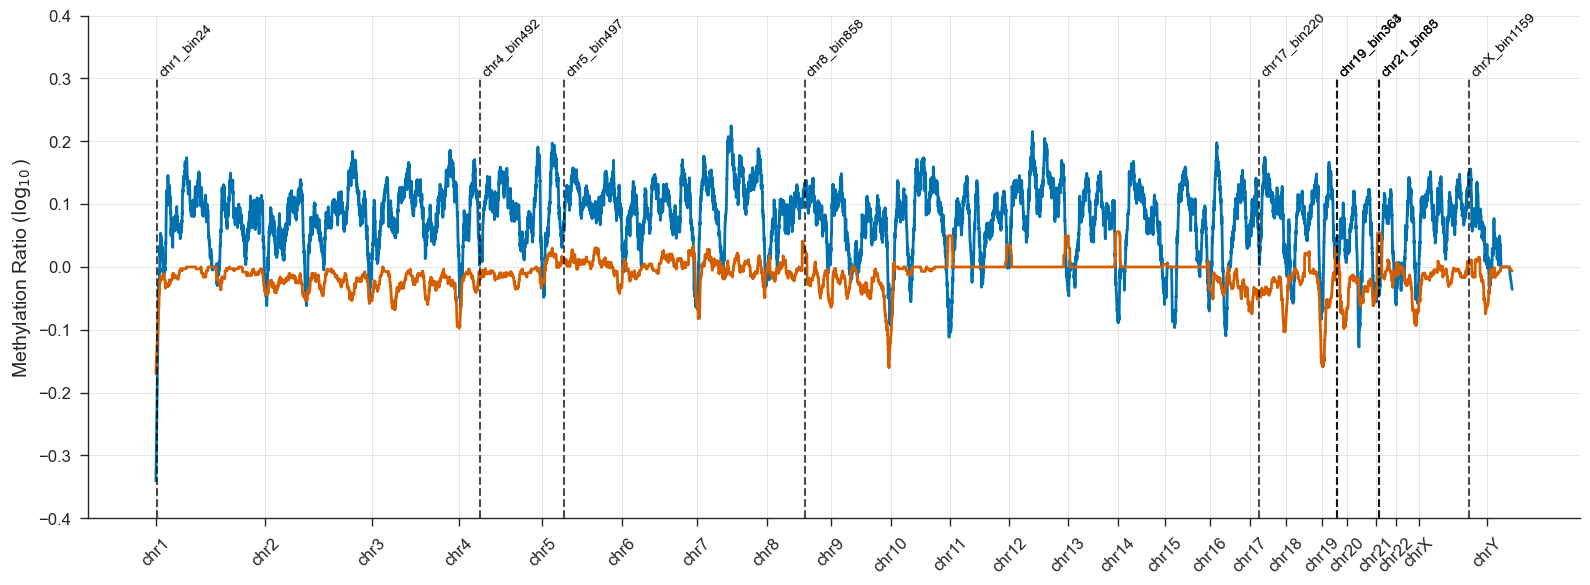

In [29]:
def create_smoothed_methylation_plot_with_highlights(bin_data, highlights, window_size=109, poly_order=1):
    """
    Creates a smoothed trend plot of methylation data using Seaborn styling and Savitzky-Golay filtering.
    Includes chromosome labels on the x-axis at the first bin of each chromosome.
    Highlights specified bins on the plot.
    """
    def get_chrom_order(chrom_str):
        chrom = chrom_str.replace('chr', '')
        if chrom.isdigit():
            return int(chrom)
        elif chrom == 'X':
            return 23
        elif chrom == 'Y':
            return 24
        else:
            return float('inf')
    
    bin_data_copy = bin_data.copy()
    bin_data_copy['chromosome'] = bin_data_copy['bin'].str.extract(r'(chr[0-9XY]+)')[0]
    bin_data_copy['bin_within_chr'] = bin_data_copy['bin'].str.extract(r'bin(\d+)')[0].astype(int)
    bin_data_copy['sort_key'] = bin_data_copy['chromosome'].apply(get_chrom_order).astype(str).str.zfill(2) + '_' + \
                     bin_data_copy['bin_within_chr'].astype(str).str.zfill(6)
    bin_data_copy = bin_data_copy.sort_values(['sort_key', 'Category'])
    sorted_bins = bin_data_copy['bin'].unique()
    bin_mapping = {bin_name: i + 1 for i, bin_name in enumerate(sorted_bins)}
    bin_data_copy['bin_number'] = bin_data_copy['bin'].map(bin_mapping)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    for category in ['Responders','Non_Responders', ]:
        category_data = bin_data_copy[bin_data_copy['Category'] == category]
        bin_stats = category_data.groupby('bin_number').agg({
            'log10(methRatio)': ['mean', 'std', 'count']
        }).reset_index()
        bin_stats.columns = ['bin_number', 'mean', 'std', 'count']
        bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])
        smoothed_mean = savgol_filter(bin_stats['mean'], window_size, poly_order)

        sns.lineplot(
            data=bin_stats,
            x='bin_number',
            y=smoothed_mean,
            label=f"{category} (Smoothed)",
            color=color_map[category],
            linewidth=2,
            alpha=1,
            ax=ax,
            legend=False,
            zorder=2
        )
    
    bin_data_copy['chrom_number'] = bin_data_copy['chromosome'].apply(get_chrom_order)
    chrom_starts = bin_data_copy.groupby('chromosome')['bin_number'].min().sort_values()
    ax.set_xticks(chrom_starts.values)
    ax.set_xticklabels(chrom_starts.index, rotation=45, ha='center', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    ax.set_xlabel('', fontsize=14)
    ax.set_ylabel('Methylation Ratio ($\log_{10}$)', fontsize=14)

    plt.ylim(-0.4, 0.4)
    plt.grid(linestyle='-', linewidth=0.5, alpha=0.7, zorder=0)
    
    
    # Highlight mann-whitney significant bins with capped lines
    for _, row in highlights.iterrows():
        highlight_bin = bin_mapping[row['Bin_Name']]
        # Draw a capped vertical line
        ax.plot([highlight_bin, highlight_bin], [-0.4, 0.3], color='black', linestyle='--', alpha=0.7)
        # Add annotations
        ax.text(highlight_bin, 0.305, row['Bin_Name'], color='black', fontsize=10, ha='left', rotation=45)
    
    plt.tight_layout()  
    sns.despine()
    plt.savefig(plots_directory/'genomic_methylation.svg')
    plt.show()

create_smoothed_methylation_plot_with_highlights(ordered_bin_methylation_data, significant_results)
